In [1]:
!nvidia-smi

Wed Sep 30 12:13:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install cupy-cuda12x opencv-python-headless numpy pandas matplotlib pillow

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import cupy as cp
import time
import os

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)
print("CuPy:", cp.__version__)

print("\nGPU Device:")
print(cp.cuda.runtime.getDeviceProperties(0)["name"].decode())

print("\nGPU is ready!")

NumPy: 2.1.3
Pandas: 2.2.3
OpenCV: 5.0.0
CuPy: 14.0.1

GPU Device:
Tesla T4

GPU is ready!


In [4]:
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow

# Create dataset folder
os.makedirs("dataset/input", exist_ok=True)

# Generate 100 test images
for i in range(100):

    # Create a random colorful image
    image = np.random.randint(
        0, 256, (256, 256, 3), dtype=np.uint8
    )

    # Add shapes for realistic image patterns
    cv2.circle(image, (128, 128), 60, (255, 255, 255), 3)
    cv2.rectangle(image, (30, 30), (100, 100), (0, 255, 0), 3)

    # Save image
    filename = f"dataset/input/image_{i+1:03d}.png"
    cv2.imwrite(filename, image)

print("Dataset generated successfully!")
print("Total images:", len(os.listdir("dataset/input")))

Dataset generated successfully!
Total images: 100


Image shape: (256, 256, 3)
Image size: 196608 bytes


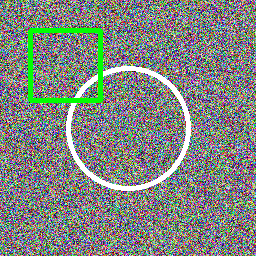

In [5]:
# Display one sample image
sample = cv2.imread("dataset/input/image_001.png")

print("Image shape:", sample.shape)
print("Image size:", sample.nbytes, "bytes")

cv2_imshow(sample)

CPU processing time: 0.017095 seconds
Grayscale output:


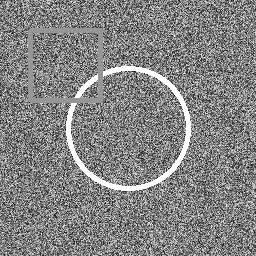

Edge detection output:


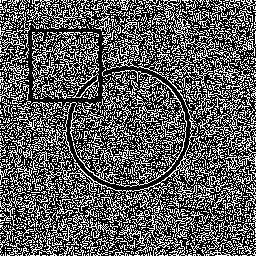

In [6]:
import time

def cpu_process(image):
    # Convert BGR image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect edges using Canny
    edges = cv2.Canny(gray, 100, 200)

    return gray, edges


# Test CPU processing
sample = cv2.imread("dataset/input/image_001.png")

start = time.perf_counter()

gray_cpu, edges_cpu = cpu_process(sample)

cpu_time = time.perf_counter() - start

print(f"CPU processing time: {cpu_time:.6f} seconds")

print("Grayscale output:")
cv2_imshow(gray_cpu)

print("Edge detection output:")
cv2_imshow(edges_cpu)

In [7]:
import cupy as cp
import numpy as np
import cv2
import time

# Custom CUDA kernel for grayscale conversion and Sobel edge detection
cuda_code = r'''
extern "C" __global__
void image_processing(
    const unsigned char* input,
    unsigned char* gray,
    unsigned char* edges,
    int width,
    int height
) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= width || y >= height)
        return;

    int idx = y * width + x;
    int color_idx = idx * 3;

    // Convert BGR to grayscale
    unsigned char b = input[color_idx];
    unsigned char g = input[color_idx + 1];
    unsigned char r = input[color_idx + 2];

    gray[idx] = (unsigned char)(
        0.114f * b + 0.587f * g + 0.299f * r
    );

    // Ignore image boundaries for Sobel
    if (x == 0 || y == 0 || x == width - 1 || y == height - 1) {
        edges[idx] = 0;
        return;
    }

    // Sobel operator
    int p00 = gray[(y-1)*width + (x-1)];
    int p01 = gray[(y-1)*width + x];
    int p02 = gray[(y-1)*width + (x+1)];

    int p10 = gray[y*width + (x-1)];
    int p12 = gray[y*width + (x+1)];

    int p20 = gray[(y+1)*width + (x-1)];
    int p21 = gray[(y+1)*width + x];
    int p22 = gray[(y+1)*width + (x+1)];

    int gx = -p00 + p02 - 2*p10 + 2*p12 - p20 + p22;
    int gy = -p00 - 2*p01 - p02 + p20 + 2*p21 + p22;

    float magnitude = sqrtf((float)(gx*gx + gy*gy));

    edges[idx] = (unsigned char)(
        magnitude > 255.0f ? 255.0f : magnitude
    );
}
'''

# Compile CUDA kernel
gpu_kernel = cp.RawKernel(cuda_code, 'image_processing')

print("Custom CUDA kernel compiled successfully!")

Custom CUDA kernel compiled successfully!


In [8]:
def gpu_process(image):

    height, width, channels = image.shape

    # Transfer input image to GPU
    gpu_input = cp.asarray(image)

    # Allocate output arrays on GPU
    gpu_gray = cp.empty((height, width), dtype=cp.uint8)
    gpu_edges = cp.empty((height, width), dtype=cp.uint8)

    # Define CUDA execution configuration
    threads = (16, 16)
    blocks = (
        (width + threads[0] - 1) // threads[0],
        (height + threads[1] - 1) // threads[1]
    )

    # Launch CUDA kernel
    gpu_kernel(
        blocks,
        threads,
        (
            gpu_input,
            gpu_gray,
            gpu_edges,
            np.int32(width),
            np.int32(height)
        )
    )

    # Wait for GPU execution to finish
    cp.cuda.Stream.null.synchronize()

    # Transfer results back to CPU
    gray = cp.asnumpy(gpu_gray)
    edges = cp.asnumpy(gpu_edges)

    return gray, edges


print("GPU processing function ready!")

GPU processing function ready!


GPU processing time: 0.613932 seconds
GPU Grayscale Output:


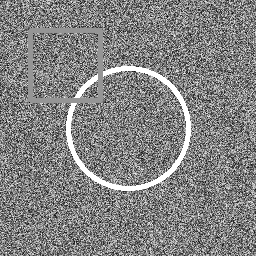

GPU Edge Detection Output:


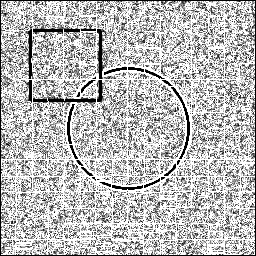

In [9]:
# Load sample image
sample = cv2.imread("dataset/input/image_001.png")

# Run GPU processing
start = time.perf_counter()

gray_gpu, edges_gpu = gpu_process(sample)

gpu_time = time.perf_counter() - start

print(f"GPU processing time: {gpu_time:.6f} seconds")

print("GPU Grayscale Output:")
cv2_imshow(gray_gpu)

print("GPU Edge Detection Output:")
cv2_imshow(edges_gpu)

In [10]:
def cpu_sobel_process(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Sobel gradients
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    # Calculate gradient magnitude
    magnitude = cv2.magnitude(gx, gy)

    # Convert to 8-bit image
    edges = np.clip(magnitude, 0, 255).astype(np.uint8)

    return gray, edges


# CPU benchmark
start = time.perf_counter()
gray_cpu, edges_cpu = cpu_sobel_process(sample)
cpu_time = time.perf_counter() - start

# GPU benchmark
start = time.perf_counter()
gray_gpu, edges_gpu = gpu_process(sample)
gpu_time = time.perf_counter() - start

print("CPU Time:", round(cpu_time, 6), "seconds")
print("GPU Time:", round(gpu_time, 6), "seconds")

if gpu_time > 0:
    print("Speedup:", round(cpu_time / gpu_time, 2), "x")

CPU Time: 0.005045 seconds
GPU Time: 0.000782 seconds
Speedup: 6.45 x


In [11]:
# CUDA kernel 1: Grayscale conversion
gray_code = r'''
extern "C" __global__
void grayscale_kernel(
    const unsigned char* input,
    unsigned char* gray,
    int width,
    int height
) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= width || y >= height) return;

    int idx = y * width + x;
    int color_idx = idx * 3;

    unsigned char b = input[color_idx];
    unsigned char g = input[color_idx + 1];
    unsigned char r = input[color_idx + 2];

    gray[idx] = (unsigned char)(
        0.114f * b + 0.587f * g + 0.299f * r
    );
}
'''

# CUDA kernel 2: Sobel edge detection
sobel_code = r'''
extern "C" __global__
void sobel_kernel(
    const unsigned char* gray,
    unsigned char* edges,
    int width,
    int height
) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= width || y >= height) return;

    int idx = y * width + x;

    if (x == 0 || y == 0 ||
        x == width - 1 || y == height - 1) {
        edges[idx] = 0;
        return;
    }

    int p00 = gray[(y-1)*width + (x-1)];
    int p01 = gray[(y-1)*width + x];
    int p02 = gray[(y-1)*width + (x+1)];

    int p10 = gray[y*width + (x-1)];
    int p12 = gray[y*width + (x+1)];

    int p20 = gray[(y+1)*width + (x-1)];
    int p21 = gray[(y+1)*width + x];
    int p22 = gray[(y+1)*width + (x+1)];

    int gx = -p00 + p02 - 2*p10 + 2*p12 - p20 + p22;
    int gy = -p00 - 2*p01 - p02 + p20 + 2*p21 + p22;

    float magnitude = sqrtf((float)(gx*gx + gy*gy));

    edges[idx] = (unsigned char)(
        magnitude > 255.0f ? 255.0f : magnitude
    );
}
'''

gray_kernel = cp.RawKernel(gray_code, "grayscale_kernel")
sobel_kernel = cp.RawKernel(sobel_code, "sobel_kernel")

print("Both CUDA kernels compiled successfully!")

Both CUDA kernels compiled successfully!


In [12]:
def gpu_process(image):

    height, width, channels = image.shape

    gpu_input = cp.asarray(image)

    gpu_gray = cp.empty((height, width), dtype=cp.uint8)
    gpu_edges = cp.empty((height, width), dtype=cp.uint8)

    threads = (16, 16)

    blocks = (
        (width + 15) // 16,
        (height + 15) // 16
    )

    # First kernel: grayscale
    gray_kernel(
        blocks,
        threads,
        (
            gpu_input,
            gpu_gray,
            np.int32(width),
            np.int32(height)
        )
    )

    # Second kernel: Sobel
    sobel_kernel(
        blocks,
        threads,
        (
            gpu_gray,
            gpu_edges,
            np.int32(width),
            np.int32(height)
        )
    )

    cp.cuda.Stream.null.synchronize()

    return cp.asnumpy(gpu_gray), cp.asnumpy(gpu_edges)


print("Updated GPU processing function ready!")

Updated GPU processing function ready!


In [13]:
import pandas as pd
import time
import os

# Load all input images
image_paths = sorted([
    f"dataset/input/{file}"
    for file in os.listdir("dataset/input")
    if file.endswith(".png")
])

images = [cv2.imread(path) for path in image_paths]

print("Total images loaded:", len(images))

batch_sizes = [10, 25, 50, 100]

results = []

for batch_size in batch_sizes:

    batch = images[:batch_size]

    # CPU benchmark
    start = time.perf_counter()

    for image in batch:
        cpu_sobel_process(image)

    cpu_total = time.perf_counter() - start

    # GPU benchmark
    start = time.perf_counter()

    for image in batch:
        gpu_process(image)

    gpu_total = time.perf_counter() - start

    speedup = cpu_total / gpu_total if gpu_total > 0 else 0

    results.append({
        "Batch Size": batch_size,
        "CPU Time (s)": cpu_total,
        "GPU Time (s)": gpu_total,
        "Speedup": speedup,
        "CPU Avg (ms/image)": (cpu_total / batch_size) * 1000,
        "GPU Avg (ms/image)": (gpu_total / batch_size) * 1000
    })

    print(f"\nBatch Size: {batch_size}")
    print(f"CPU Time: {cpu_total:.4f} seconds")
    print(f"GPU Time: {gpu_total:.4f} seconds")
    print(f"Speedup: {speedup:.2f}x")

df = pd.DataFrame(results)

df

Total images loaded: 100

Batch Size: 10
CPU Time: 0.0097 seconds
GPU Time: 0.0847 seconds
Speedup: 0.11x

Batch Size: 25
CPU Time: 0.0071 seconds
GPU Time: 0.0074 seconds
Speedup: 0.97x

Batch Size: 50
CPU Time: 0.0219 seconds
GPU Time: 0.0155 seconds
Speedup: 1.41x

Batch Size: 100
CPU Time: 0.0580 seconds
GPU Time: 0.0534 seconds
Speedup: 1.09x


,Batch Size,CPU Time (s),GPU Time (s),Speedup,CPU Avg (ms/image),GPU Avg (ms/image)
0,10,0.009729,0.084724,0.114830,0.972888,8.472415
1,25,0.007136,0.007373,0.967955,0.285452,0.294903
2,50,0.021926,0.015529,1.411969,0.438530,0.310580
3,100,0.057970,0.053355,1.086512,0.579705,0.533546


In [14]:
os.makedirs("results", exist_ok=True)

df.to_csv("results/performance_results.csv", index=False)

print("CSV report saved successfully!")
print("Location: results/performance_results.csv")

df

CSV report saved successfully!
Location: results/performance_results.csv


,Batch Size,CPU Time (s),GPU Time (s),Speedup,CPU Avg (ms/image),GPU Avg (ms/image)
0,10,0.009729,0.084724,0.114830,0.972888,8.472415
1,25,0.007136,0.007373,0.967955,0.285452,0.294903
2,50,0.021926,0.015529,1.411969,0.438530,0.310580
3,100,0.057970,0.053355,1.086512,0.579705,0.533546


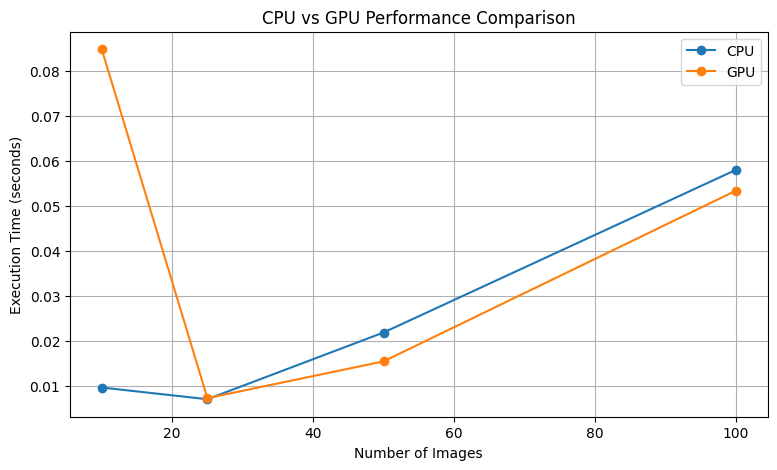

In [15]:
import matplotlib.pyplot as plt

# CPU vs GPU execution time
plt.figure(figsize=(9, 5))

plt.plot(
    df["Batch Size"],
    df["CPU Time (s)"],
    marker="o",
    label="CPU"
)

plt.plot(
    df["Batch Size"],
    df["GPU Time (s)"],
    marker="o",
    label="GPU"
)

plt.xlabel("Number of Images")
plt.ylabel("Execution Time (seconds)")
plt.title("CPU vs GPU Performance Comparison")
plt.legend()
plt.grid(True)

plt.savefig("results/cpu_vs_gpu.png", dpi=300)
plt.show()

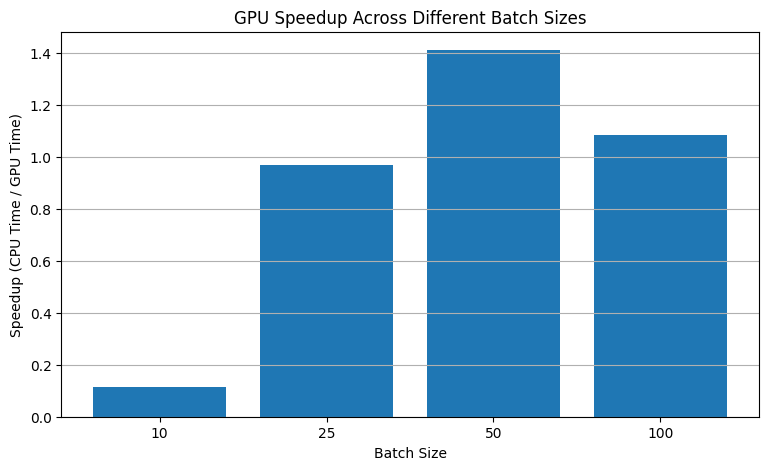

In [16]:
plt.figure(figsize=(9, 5))

plt.bar(
    df["Batch Size"].astype(str),
    df["Speedup"]
)

plt.xlabel("Batch Size")
plt.ylabel("Speedup (CPU Time / GPU Time)")
plt.title("GPU Speedup Across Different Batch Sizes")
plt.grid(axis="y")

plt.savefig("results/gpu_speedup.png", dpi=300)
plt.show()

In [17]:
os.makedirs("results/output_images", exist_ok=True)

sample = images[0]

gray_result, edge_result = gpu_process(sample)

cv2.imwrite(
    "results/output_images/grayscale.png",
    gray_result
)

cv2.imwrite(
    "results/output_images/sobel_edges.png",
    edge_result
)

print("Processed images saved successfully!")

Processed images saved successfully!


Mean grayscale difference: 0.4970703
Mean edge difference: 3.0296326


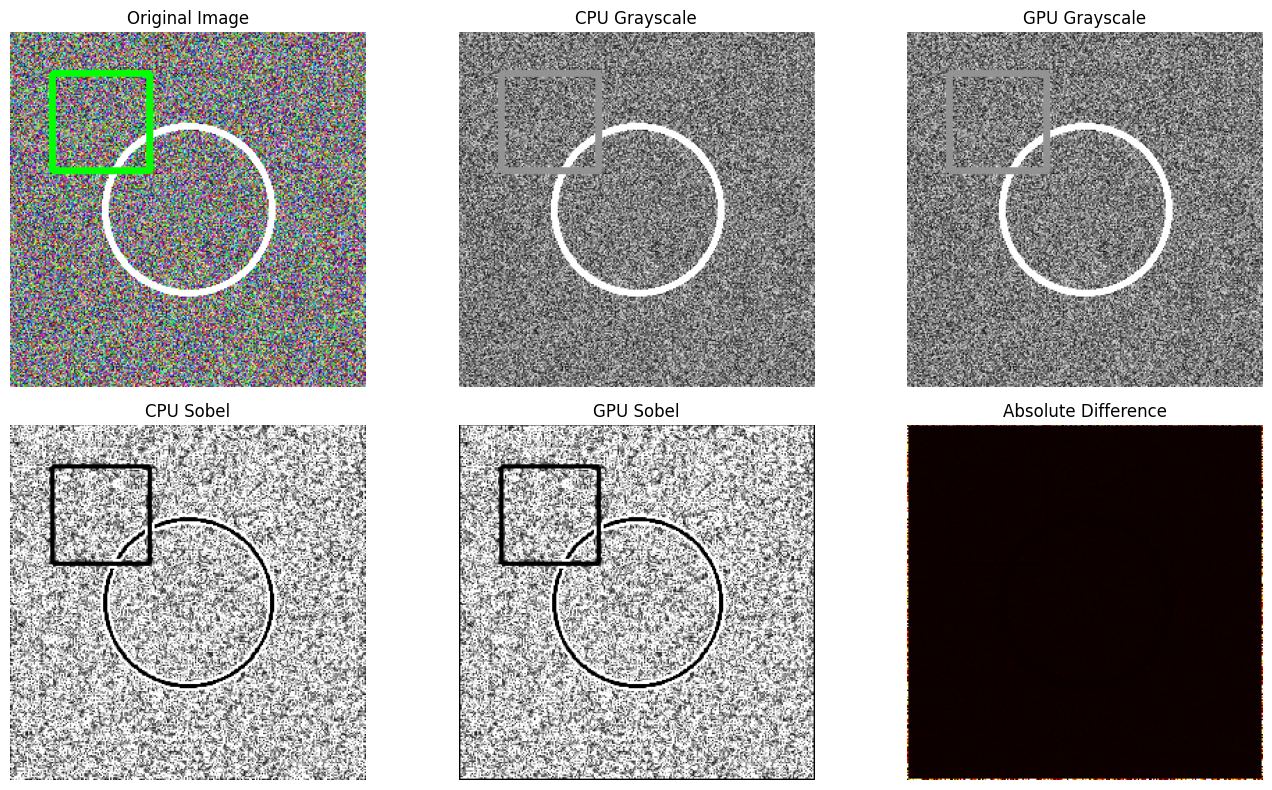

In [18]:
import matplotlib.pyplot as plt

sample = images[0]

# CPU output
gray_cpu, edges_cpu = cpu_sobel_process(sample)

# GPU output
gray_gpu, edges_gpu = gpu_process(sample)

# Compare outputs
gray_difference = np.mean(
    np.abs(gray_cpu.astype(np.float32) - gray_gpu.astype(np.float32))
)

edge_difference = np.mean(
    np.abs(edges_cpu.astype(np.float32) - edges_gpu.astype(np.float32))
)

print("Mean grayscale difference:", gray_difference)
print("Mean edge difference:", edge_difference)

# Display comparison
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original Image")

axes[0, 1].imshow(gray_cpu, cmap="gray")
axes[0, 1].set_title("CPU Grayscale")

axes[0, 2].imshow(gray_gpu, cmap="gray")
axes[0, 2].set_title("GPU Grayscale")

axes[1, 0].imshow(edges_cpu, cmap="gray")
axes[1, 0].set_title("CPU Sobel")

axes[1, 1].imshow(edges_gpu, cmap="gray")
axes[1, 1].set_title("GPU Sobel")

axes[1, 2].imshow(
    np.abs(edges_cpu.astype(np.int16) - edges_gpu.astype(np.int16)),
    cmap="hot"
)
axes[1, 2].set_title("Absolute Difference")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.savefig("results/output_comparison.png", dpi=300)
plt.show()

In [19]:
!nvidia-smi

Wed Sep 30 12:20:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             31W /   70W |     107MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [20]:
from datetime import datetime
import platform

log_text = f"""
GPU CAPSTONE PROJECT - EXECUTION LOG

Project: GPU-Powered Image Processing and Performance Analyzer
Execution Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

Environment:
Python Version: {platform.python_version()}
NumPy Version: {np.__version__}
Pandas Version: {pd.__version__}
CuPy Version: {cp.__version__}
OpenCV Version: {cv2.__version__}

GPU Device: Tesla T4
Input Images: {len(images)}
Image Resolution: 256 x 256

CUDA Operations:
1. Grayscale Conversion
2. Sobel Edge Detection

Performance Results:
{df.to_string(index=False)}

Output:
CPU and GPU benchmark completed.
CSV report generated.
Performance graphs generated.
Processed images saved.
"""

with open("results/execution_log.txt", "w") as f:
    f.write(log_text)

print(log_text)


GPU CAPSTONE PROJECT - EXECUTION LOG

Project: GPU-Powered Image Processing and Performance Analyzer
Execution Date: 2026-09-30 12:20:18

Environment:
Python Version: 3.13.15
NumPy Version: 2.1.3
Pandas Version: 2.2.3
CuPy Version: 14.0.1
OpenCV Version: 5.0.0

GPU Device: Tesla T4
Input Images: 100
Image Resolution: 256 x 256

CUDA Operations:
1. Grayscale Conversion
2. Sobel Edge Detection

Performance Results:
 Batch Size  CPU Time (s)  GPU Time (s)  Speedup  CPU Avg (ms/image)  GPU Avg (ms/image)
         10      0.009729      0.084724 0.114830            0.972888            8.472415
         25      0.007136      0.007373 0.967955            0.285452            0.294903
         50      0.021926      0.015529 1.411969            0.438530            0.310580
        100      0.057970      0.053355 1.086512            0.579705            0.533546

Output:
CPU and GPU benchmark completed.
CSV report generated.
Performance graphs generated.
Processed images saved.



In [21]:
import shutil
import os

project_dir = "GPU_Capstone_Project"

os.makedirs(project_dir, exist_ok=True)

# Copy results
shutil.copytree(
    "results",
    f"{project_dir}/results",
    dirs_exist_ok=True
)

# Copy input dataset
shutil.copytree(
    "dataset/input",
    f"{project_dir}/dataset/input",
    dirs_exist_ok=True
)

print("Project files organized successfully!")

Project files organized successfully!


In [22]:
readme = """
# GPU-Powered Image Processing and Performance Analyzer

## Overview
This project demonstrates GPU acceleration using CUDA for batch image processing.

## Features
- Custom CUDA grayscale conversion kernel
- Custom CUDA Sobel edge detection kernel
- CPU vs GPU performance comparison
- Batch benchmarking for 10, 25, 50 and 100 images
- Execution time and speedup calculation
- CSV performance report
- Performance graphs
- Output image comparison

## Technology Stack
- Python
- NVIDIA CUDA
- CuPy
- NumPy
- OpenCV
- Pandas
- Matplotlib
- Google Colab

## Hardware
NVIDIA Tesla T4 GPU

## Results
The results folder contains:
- performance_results.csv
- cpu_vs_gpu.png
- gpu_speedup.png
- output_comparison.png
- execution_log.txt
- Processed output images

## Execution
Open GPU_Capstone_Image_Processing.ipynb in Google Colab.
Enable GPU runtime and execute cells sequentially.

## Note
Benchmark timings include data transfer and processing overhead.
Actual speedup depends on batch size and runtime conditions.
"""

with open(f"{project_dir}/README.md", "w") as f:
    f.write(readme)

print("README created!")

README created!


In [23]:
shutil.make_archive(
    "GPU_Capstone_Final",
    "zip",
    project_dir
)

print("Final ZIP created successfully!")

Final ZIP created successfully!


In [24]:
from google.colab import files

files.download("GPU_Capstone_Final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>